# Load and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/training_set_VU_DM.csv")

In [5]:
print(df.shape)
df.head()

(4958347, 54)


,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


# Part 4 - Data Preparation

## 4.1 Data Cleaning

### 4.1.1 Data Types

In [6]:
# Adding Date
df["date_time"] = pd.to_datetime(df["date_time"])
date_col = df["date_time"].dt.floor("D")
df.insert(2, "date", date_col)
df.head()

,srch_id,date_time,date,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,893,3,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,10404,4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,21315,3,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,27348,2,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,2013-04-04,12,187,NaN,NaN,219,29604,4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


In [7]:
cont_cols = ['visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_review_score', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'price_usd', 'srch_query_affinity_score', 'orig_destination_distance', 'gross_bookings_usd', 'comp1_rate_percent_diff', 'comp2_rate_percent_diff', 'comp3_rate_percent_diff', 'comp4_rate_percent_diff', 'comp5_rate_percent_diff', 'comp6_rate_percent_diff', 'comp7_rate_percent_diff', 'comp8_rate_percent_diff']

bool_cols = ['prop_brand_bool', 'promotion_flag', 'srch_saturday_night_bool', 'random_bool', 'click_bool', 'booking_bool']

id_cols = ['srch_id', 'site_id', 'visitor_location_country_id', 'prop_country_id', 'prop_id', 'srch_destination_id']

cat_cols = ['prop_starrating', 'comp1_rate', 'comp1_inv', 'comp2_rate', 'comp2_inv', 'comp3_rate', 'comp3_inv', 'comp4_rate', 'comp4_inv', 'comp5_rate', 'comp5_inv', 'comp6_rate', 'comp6_inv', 'comp7_rate', 'comp7_inv', 'comp8_rate', 'comp8_inv']

int_cols = ['position', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count']

time_cols = ['date_time', 'date']

In [8]:
# Checking Column Numbers
print(df.shape[1])
col_len = len(cont_cols) + len(bool_cols) + len(id_cols) + len(int_cols) + len(time_cols) + len(cat_cols)
print(col_len)

55
55


In [9]:
# Converting Data Types
df[cont_cols] = df[cont_cols].astype('float32')
df[bool_cols] = df[bool_cols].astype('bool')
df[id_cols + cat_cols] = df[id_cols + cat_cols].astype('category')
df[int_cols] = df[int_cols].astype('int8')

In [10]:
df.dtypes

srch_id                              category
date_time                      datetime64[ns]
date                           datetime64[ns]
site_id                              category
visitor_location_country_id          category
visitor_hist_starrating               float32
visitor_hist_adr_usd                  float32
prop_country_id                      category
prop_id                              category
prop_starrating                      category
prop_review_score                     float32
prop_brand_bool                          bool
prop_location_score1                  float32
prop_location_score2                  float32
prop_log_historical_price             float32
position                                 int8
price_usd                             float32
promotion_flag                           bool
srch_destination_id                  category
srch_length_of_stay                      int8
srch_booking_window                      int8
srch_adults_count                 

### 4.1.2 Target Engineering

In [18]:
df["target"] = 5 * df["booking_bool"] + 1 * df["click_bool"]
df["target"] = df["target"].astype("int8")

In [19]:
df.dtypes[-3:]

booking_bool                   bool
booking_window_was_negative    bool
target                         int8
dtype: object

### 4.1.3 Dropping Columns of Leakage

In [21]:
# Main ranking target
y = df["target"]

# Auxiliary target for predicted_position model
position_target = df["position"]

# Remove leakage/target columns
df = df.drop(columns=[
    "target",
    "booking_bool",
    "click_bool",
    "gross_bookings_usd",
    "position"
])

In [22]:
df.shape

(4958347, 52)

### 4.1.4 Capping wrong values and outliers

### Search Booking Window

In [11]:
# Create Negative Flag Feature for booking_window
df["booking_window_was_negative"] = (df["srch_booking_window"] < 0).astype("bool")

# Clip Values
df["srch_booking_window"] = df["srch_booking_window"].clip(lower = 0)

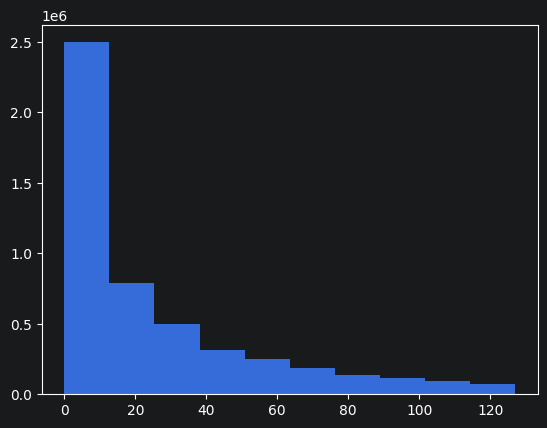

In [12]:
plt.figure()
plt.hist(df["srch_booking_window"])
plt.show()

### Competition Rate Diff

In [ ]:
upper_limit = 150
for i in range(1, 9):
    df[f"comp{i}_rate_percent_diff"] = df[f"comp{i}_rate_percent_diff"].clip(upper = upper_limit)
    plt.figure()
    plt.hist(df[f"comp{i}_rate_percent_diff"])
    plt.title(f"Distribution of comp{i}_rate_percent_diff")
    plt.show()

### Train-Validation Split

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    test_size=0.2,
    n_splits=1,
    random_state=42
)

train_idx, val_idx = next(
    splitter.split(df, groups=df['srch_id'])
)

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]

### Price USD

In [ ]:
# Create quantile using only Training Set
price_995 = train_df["price_usd"].quantile(q = 0.995)

# Cap for both Train and Validation Set
train_df["price_usd"] = train_df["price_usd"].clip(upper = price_995)
val_df["price_usd"] = val_df["price_usd"].clip(upper = price_995)

### 4.1.5 Handling Null and 0 Values

Property Starrating